# Predicción del fútbol uruguayo: selección temporal y evaluación final de NB

La selección de Naive Bayes usa exclusivamente resultados hasta 2023 y queda
cerrada antes de la evaluación 2024–2025. La sección 14 presenta el reajuste de
ambos NB con los diez atributos seleccionados y su comparación con el baseline
causal de diez años, sobre exactamente los mismos partidos admitidos.

`python3.12 scripts/evaluate_final_nb.py` reproduce esa evaluación sin ejecutar
ID3 ni Random Forest. Por defecto, el notebook verifica y lee los resultados de
`results/naive_bayes/final/`; las celdas legadas de árboles siguen desactivadas
(`RUN_FINAL_TEST = False`). La selección y las corridas históricas de los otros
modelos conservan sus artefactos y manifiestos originales.

La selección NB previa se documenta en `docs/nb_selection.md`; la evaluación
final, en `docs/nb_final_evaluation.md`.


## 1. Configuración

Entorno de la consigna: Python 3.12 y scikit-learn 1.9. Los módulos de `src/`
comparten la política de datos, historiales y validación. La semilla es 42.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

ROOT = Path.cwd()
if not (ROOT / 'requirements.txt').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from features import (  # noqa: E402
    NUMERIC_FEATURES,
    build_causal_match_features,
    load_clean_matches,
)
from baseline import TenYearWinRateClassifier  # noqa: E402
from id3 import ID3  # noqa: E402
from naive_bayes import MEstimateCategoricalNB  # noqa: E402
from preprocessing import MixedTypeDiscretizer  # noqa: E402
from baseline import BASELINE_FEATURES  # noqa: E402
from evaluation import (  # noqa: E402
    temporal_holdout, make_temporal_folds,
    new_discretizer, evaluate_temporal_cv,
)

RAW = ROOT / 'data/raw/futbol_uruguayo.zip'
CLASSES = ['E', 'L', 'V']
BIN_ORDER = ['baja', 'media', 'alta']
RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)


def entropia(series: pd.Series) -> float:
    """Entropia de Shannon en bits de una serie de etiquetas."""
    probs = series.value_counts(normalize=True)
    return float(-(probs * np.log2(probs)).sum())

## 2. Datos: lectura, auditoría y limpieza del ZIP

`load_clean_matches(..., through_year=2023)` separa por fecha antes de interpretar
marcadores o construir etiquetas y aplica la política de `docs/data_policy.md` antes de crear
etiquetas o historiales: elimina repeticiones exactas, pone en cuarentena todas
las variantes de una fecha/par de equipos ambiguo (incluida localía invertida)
y excluye los registros `full_time=E/P`, cuyos goles a los 90 minutos no están
separados. No elige un marcador entre variantes ni reconstruye goles.

En los registros `F` conservados, `winner` es `L` si `gh > ga`, `V` si `gh < ga`
y `E` si son iguales. `full_time=E` significa prórroga, no la etiqueta empate.
Los goles del partido no son entradas. La auditoría reproducible, con líneas
del CSV y alertas adicionales de equipo/fecha, está en `docs/data_audit/`.


In [2]:
# La primera pasada lee solo fechas; no se interpretan resultados posteriores.
matches = load_clean_matches(RAW, through_year=2023)
print('Filas limpias:', len(matches))
display(matches.head(3))
display(matches.dtypes.to_frame(name='tipo'))
print('Distribucion de la clase (hasta 2023):')
display(
    matches['winner']
    .value_counts()
    .reindex(CLASSES)
    .rename('cantidad')
    .to_frame()
)

Filas limpias: 14705
Distribucion de la clase (hasta 2023):


,home,away,date,gh,ga,full_time,winner,year,month
0,Bella Vista,Defensor Sporting,1932-03-05,1,2,F,V,1932,3
1,CA Penarol,River Plate,1932-03-05,1,1,F,E,1932,3
2,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1,0,F,L,1932,3


,tipo
home,string[python]
away,string[python]
date,datetime64[ns]
gh,int64
ga,int64
full_time,string[python]
winner,object
year,int64
month,int64


,cantidad
winner,
E,4029
L,6545
V,4131


## 3. Atributos causales (sin mirar el futuro)

`build_causal_match_features` construye, para cada partido, tasas historicas calculadas **con fechas estrictamente anteriores**. Los partidos de un mismo dia se featurizan todos antes de actualizar los historiales, de modo que un partido jamas usa el resultado de otro partido del mismo dia (esto evita **leakage**).

El modelo usa 6 tasas de victoria:

- `home/away_win_rate_last_5`: forma de cada equipo en sus ultimos 5 partidos;
- `home/away_win_rate_season`: exito de cada equipo dentro del ano calendario;
- `home_win_rate_as_home_all`: historico del local actuando de local;
- `home_win_rate_h2h_as_home`: historico del local contra ese visitante con la misma localia (head-to-head orientado).

Cuando un equipo **no tiene historial** (debut, primera vez en la ventana o primer partido del ano) el denominador es 0 y se imputa un neutro de `0.5` en lugar de `0.0`, para separarlo de cero victorias; el neutro puede coincidir con una tasa real de 0.5.

El baseline usa las tasas causales de diez años del **mismo constructor**, con
los mismos partidos admitidos y el mismo valor neutro. Todos los modelos
pueden usar resultados de fechas anteriores de validación/test; ninguno usa
resultados de la fecha actual y ninguno se reajusta dentro de ese bloque.

In [3]:
featured = build_causal_match_features(matches)
print('Partidos con atributos:', len(featured))
display(featured[['date', 'home', 'away'] + NUMERIC_FEATURES + ['winner']].head(5))

sin_historial = featured[featured['home_win_rate_season'].eq(0.5)]
print('Tasa 0.5: puede ser imputada o una proporción real, no prueba ausencia de historial:')
display(sin_historial[['date', 'home', 'away'] + NUMERIC_FEATURES].head(3))

Partidos con atributos: 14705
Tasa 0.5: puede ser imputada o una proporción real, no prueba ausencia de historial:


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,winner
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,V
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,E
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,L
3,1932-03-05,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,L
4,1932-03-05,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,L


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5


## 4. Partición temporal y folds comunes

- Entrenamiento final: hasta 2023 inclusive.
- Evaluación reservada: 2024–2025.
- Validación: años completos 2021, 2022 y 2023, entrenando con todos los años
  anteriores a cada bloque. No se separan partidos de una misma fecha.

`CV_FOLDS` es la única definición de folds para ID3, NB, baseline y comparadores.
Cada llamada a `evaluate_temporal_cv` ajusta un pipeline nuevo por fold, con
selección de entradas y, cuando corresponde, discretización aprendida solo en
ese entrenamiento. Las métricas de test no seleccionan parámetros.


In [4]:
train = featured.reset_index(drop=True)
assert train['date'].dt.year.le(2023).all()
CV_FOLDS = make_temporal_folds(train)
print('Partidos disponibles para selección:', len(train))
print('No se construyen atributos ni se evalúa el período 2024–2025.')
print('Folds compartidos:')
display(pd.DataFrame([
    {'validacion': fold.validation_year,
     'train_hasta': train.iloc[list(fold.train_positions)]['date'].max().date(),
     'validacion_desde': train.iloc[list(fold.validation_positions)]['date'].min().date(),
     'validacion_hasta': train.iloc[list(fold.validation_positions)]['date'].max().date(),
     'n_train': len(fold.train_positions),
     'n_validacion': len(fold.validation_positions)}
    for fold in CV_FOLDS
]))


Partidos disponibles para selección: 14705
No se construyen atributos ni se evalúa el período 2024–2025.
Folds compartidos:


,validacion,train_hasta,validacion_desde,validacion_hasta,n_train,n_validacion
0,2021,2020-12-19,2021-01-13,2021-12-06,13744,364
1,2022,2021-12-06,2022-02-05,2022-10-24,14108,297
2,2023,2022-10-24,2023-02-04,2023-12-16,14405,300


## 5. Discretización

ID3 y Naive Bayes categórico reciben códigos enteros. Las tasas de los últimos
cinco partidos usan cortes fijos `[0.3, 0.6]`; con menos de cinco antecedentes
se calcula la proporción sobre los disponibles. Las otras tasas usan terciles
aprendidos en entrenamiento. Los valores repetidos pueden producir tamaños
desiguales o menos de tres intervalos. No hay categoría exclusiva sin historial.

Aquí se prepara la transformación final con todo train; **no** se reutiliza en
validación cruzada, que crea su propio discretizador dentro de cada fold.


In [ ]:
discretizer = new_discretizer()
discretizer.fit(train[NUMERIC_FEATURES])

print('Bordes de cada atributo (dos cortes -> tres bines):')
display(
    pd.DataFrame(
        {column: discretizer.numeric_edges_[column] for column in NUMERIC_FEATURES}
    ).T.rename(columns={0: 'borde_1', 1: 'borde_2'})
)

X_train = discretizer.transform(train[NUMERIC_FEATURES])

print('Ejemplo: la tasa cruda y el codigo que recibe ID3 (1=baja, 2=media, 3=alta):')
muestra = train[['home', 'away'] + NUMERIC_FEATURES].head(5).copy()
all_columns = [column for column in NUMERIC_FEATURES]
codigos = pd.DataFrame(
    X_train[:5], columns=[column + '_cod' for column in NUMERIC_FEATURES]
)
display(pd.concat([muestra, codigos], axis=1))

print('Cuantas filas de train cae en cada categoria:')
resumen = pd.DataFrame({column: pd.Series(X_train[:, i]).map(
    {1: 'baja', 2: 'media', 3: 'alta'}
).value_counts() for i, column in enumerate(NUMERIC_FEATURES)})
display(resumen.reindex(BIN_ORDER).fillna(0).astype(int))

## 6. Como decide el arbol: entropia y ganancia

ID3 elige el atributo que mas reduce la **entropia** (desorden) de la clase. La entropia de la clase en train es:

```text
H(Y) = -sum_c P(c) * log2(P(c))
```

que mide cuantos bits de informacion hacen falta para decir el resultado sabiendo solo la distribucion global. La **ganancia de informacion** de un atributo es la entropia menos la entropia condicional promedio tras partir por ese atributo.

En este paso calculamos **la primera decision que tomaria el arbol** mostrando la ganancia de cada atributo sobre todo train.

In [ ]:
parent_entropy = entropia(train['winner'])
print(f'Entropia de la clase en train: {parent_entropy:.4f} bits '
      '(maximo teorico ~1.585 bits para 3 clases equiprobables)')

gains = []
for index, column in enumerate(NUMERIC_FEATURES):
    conditional = 0.0
    for code in np.unique(X_train[:, index]):
        mask = X_train[:, index] == code
        conditional += mask.mean() * entropia(train['winner'][mask])
    gains.append({
        'atributo': column,
        'entropia_condicional': round(conditional, 4),
        'ganancia': round(parent_entropy - conditional, 4),
    })
gains_frame = pd.DataFrame(gains).sort_values('ganancia', ascending=False)
display(gains_frame.reset_index(drop=True))

mejor = gains_frame.iloc[0]
print(
    f'Primera division sobre {mejor["atributo"]} '
    f'(ganancia {mejor["ganancia"]:.4f} bits).'
)

## 7. Naive Bayes propio

Ahora usamos `MEstimateCategoricalNB` (`src/naive_bayes.py`) con los mismos partidos, inicialmente las seis tasas de `NUMERIC_FEATURES` y las clases `E`, `L`, `V`. Naive Bayes combina la frecuencia de cada clase con las probabilidades de los atributos y supone que estos son **independientes entre si dada la clase**.

Esta implementacion es **categorica**: requiere entradas discretas, codificadas como enteros no negativos. Reutilizamos la configuracion de `MixedTypeDiscretizer` de la seccion 5: tres bines, cortes fijos para las tasas de los ultimos cinco partidos y cuantiles para las restantes. El discretizador existente se ajusto solo con train; para validar necesitamos instancias nuevas ajustadas solo con el entrenamiento de cada fold.

El suavizado **m-estimate** evita probabilidades condicionales nulas:

\[
P(X_j=v \mid Y=c) = \frac{n_{jvc} + m\,p_{jv}}{n_c + m}
\]

Aqui `n_jvc` cuenta los partidos de clase `c` cuyo atributo `j` tiene codigo `v`, y `n_c` cuenta los partidos de esa clase. El prior `p_jv = 1 / K_j` es uniforme sobre los codigos posibles, incluido el `0` reservado para desconocidos. Por defecto `K_j=max(X_train[:,j])+1`; `min_categories` permite declarar un dominio mayor sin mirar validacion/test. En esta grilla ambos NB declaran cuatro codigos, aunque un bin no aparezca en train. `m > 0` es el peso total del prior: cuanto mayor es, mas se acercan las condicionales a la distribucion uniforme. La consigna no fija el prior; elegimos el uniforme, no las frecuencias marginales.

**Como leer `src/naive_bayes.py`, paso a paso:**

1. **`_validate_X`** comprueba que cada fila sea un partido y que los valores sean codigos enteros no negativos. Las tasas se discretizan antes de entrar al modelo; los codigos son categorias, no cantidades.
2. **`fit(X, y)`** aprende dos cosas: la frecuencia de cada resultado `P(c)` y una tabla por atributo con `P(codigo | c)`. `np.unique` convierte etiquetas en indices y `np.bincount` cuenta apariciones. En cada tabla, las filas son clases y las columnas son codigos.
3. **Suavizado:** si hay 10 partidos de clase `L`, un codigo aparece en 3 y hay 4 codigos posibles (incluido el `0`), con `m=2` la probabilidad es `(3 + 2/4) / (10 + 2) = 0.292`. Incluso un codigo sin apariciones recibe algo de probabilidad. Este suavizado se aplica a las tablas de atributos, no a `P(c)`.
4. **`_joint_log_likelihood`** puntua cada clase para un partido: parte de `log P(c)` y suma el log de la probabilidad de cada uno de sus codigos. Asi implementa el producto de Naive Bayes sin multiplicar numeros muy pequenos:

\[
\mathrm{puntaje}(c) = \log P(c) + \sum_j \log P(X_j=x_j \mid c).
\]

5. **Las salidas:** `predict` elige la clase de mayor puntaje; `predict_proba` usa `softmax` para convertir los puntajes en probabilidades que suman 1; `predict_log_proba` normaliza directamente en log con `logsumexp`, evitando tomar el logaritmo de una probabilidad redondeada a cero. Las columnas siguen el orden de `classes_`. Si llega un codigo fuera del dominio aprendido/declarado, se usa el codigo reservado `0`.

Por ejemplo, para `[3, 1, 2, 2, 3, 1]`, se busca cada codigo en la tabla de su atributo y se suman sus aportes para `E`, `L` y `V`. No se suma el valor numerico de los codigos: se suman los **logs de sus probabilidades**. Para elegir la clase no hace falta calcular `P(X)`, porque es el mismo divisor para las tres.


## 8. Grillas y regla de selección

Los folds son los mismos años completos 2021, 2022 y 2023. Cada combinación
ajusta un pipeline nuevo por fold, sin usar los cuantiles de otro entrenamiento.
Se selecciona por **macro-F1 medio de validación**, con igual peso por año y
las clases fijas E/L/V. El error es `1 - accuracy`; el de entrenamiento es de
resustitución y sirve como diagnóstico, no como estimación de generalización.

- ID3: `min_info_gain = [0, 0.001, 0.005, 0.01, 0.02, 0.05]`.
- NB propio: `m = [0.1, 1, 10, 100, 1000]`, `min_categories=4`.
- CategoricalNB: `alpha = [0.025, 0.25, 2.5, 25, 250]`, `min_categories=4`.
- Random Forest: `max_depth = [4, 8, None]` y
  `min_samples_leaf = [50, 20, 5, 1]`; 300 árboles, semilla 42,
  `class_weight='balanced_subsample'`.

Ante empate exacto se elige el menor umbral/m/alpha; para el bosque, la menor
profundidad y luego la mayor hoja. Se conserva el bosque sin límite/hoja 1,
los dos DecisionTree con entropía (códigos y tasas) y el baseline de diez años.

Con el mismo dominio de cuatro códigos por atributo en ambos NB, el suavizado uniforme propio equivale a
`alpha=m/4`. Las grillas de ambos NB permiten comparar esa correspondencia;
no se espera que dos implementaciones de la misma fórmula sean necesariamente
dos métodos estadísticos distintos. El manifiesto registra las cardinalidades
observadas de cada fold. En general se necesita `alpha_j=m/K_j`: un único `alpha` solo es equivalente si todos los atributos tienen igual `K_j`, el mismo prior de clase y la misma codificación de desconocidos. Ver [la revisión de NB](docs/naive_bayes.md).

Para reproducir la búsqueda (solo entrenamiento/validación):
`python3.12 scripts/run_validation.py`. Para regenerar solo la selección NB consolidada:
`python3.12 scripts/consolidate_nb.py`.


In [5]:
import json
from nb_selection import NB_MODELS, load_nb_manifest, training_fingerprint, final_nb_pipelines

NB_RESULTS = ROOT / 'results/naive_bayes'
nb_manifest = load_nb_manifest(ROOT)  # Código actual, resultados nuevos y referencias históricas.
assert nb_manifest['training_sha256'] == training_fingerprint(matches)
assert nb_manifest['rows'] == len(train)
assert [f['validation_year'] for f in nb_manifest['folds']] == [2021, 2022, 2023]

def replace_nb_rows(historical, current):
    return pd.concat([historical.loc[~historical.model.isin(NB_MODELS)], current], ignore_index=True)

VALIDATION_DIR = ROOT / 'results/validation'
cv_details = replace_nb_rows(pd.read_csv(VALIDATION_DIR / 'fold_metrics.csv'),
                            pd.read_csv(NB_RESULTS / 'validation_folds.csv'))
cv_summary = replace_nb_rows(pd.read_csv(VALIDATION_DIR / 'grid_summary.csv'),
                            pd.read_csv(NB_RESULTS / 'validation_summary.csv'))
cv_selected = replace_nb_rows(pd.read_csv(VALIDATION_DIR / 'selected.csv'),
                             pd.read_csv(NB_RESULTS / 'validation_selected.csv'))
print('NB revalidado:', nb_manifest['python'], 'scikit-learn', nb_manifest['scikit_learn'])
print('Otros modelos: resultados históricos conservados; no reentrenados en esta revisión.')
print('Seleccionados por macro-F1 medio anual, antes de redondear:')
display(cv_selected[['model', 'parameters', 'macro_f1_mean', 'macro_f1_std',
                     'validation_error_mean', 'train_error_mean']].round(6))
selected_params = {row.model: json.loads(row.parameters) for row in cv_selected.itertuples()}
id3_gain_elegido = selected_params['ID3']['min_info_gain']
nb_m_elegido = selected_params['NB propio']['m']
nb_alpha_elegido = selected_params['CategoricalNB']['alpha']
rf_params_elegidos = selected_params['Random Forest']
id3_cv = cv_summary.loc[cv_summary.model.eq('ID3')].copy()
id3_cv['min_info_gain'] = id3_cv.parameters.map(lambda p: json.loads(p)['min_info_gain'])
nb_cv = cv_summary.loc[cv_summary.model.eq('NB propio')].copy()
nb_cv['m'] = nb_cv.parameters.map(lambda p: json.loads(p)['m'])
nb_cv['macro_f1_medio'] = nb_cv['macro_f1_mean']


NB revalidado: 3.12.14 scikit-learn 1.9.1
Otros modelos: resultados históricos conservados; no reentrenados en esta revisión.
Seleccionados por macro-F1 medio anual, antes de redondear:


,model,parameters,macro_f1_mean,macro_f1_std,validation_error_mean,train_error_mean
0,Base 10 años,{},0.350521,0.008642,0.547660,0.524971
1,ID3,"{""min_info_gain"": 0.005}",0.381798,0.016158,0.576739,0.473186
2,Random Forest,"{""max_depth"": null, ""min_samples_leaf"": 20}",0.422767,0.009563,0.565298,0.403547
3,sklearn DT (códigos),{},0.379811,0.014377,0.580804,0.472063
4,sklearn DT (tasas),{},0.341531,0.018977,0.648557,0.001159
5,CategoricalNB,"{""alpha"": 0.025}",0.363482,0.032202,0.565633,0.516039
6,NB propio,"{""m"": 0.1}",0.363482,0.032202,0.565633,0.516039


## 9. Curvas de error y selección de suavizado

Estas curvas corresponden a la búsqueda original sobre **seis tasas**, repetida
con el código actual. El error es **1 − accuracy**; cada punto es la media simple
de los años 2021, 2022 y 2023. La curva de entrenamiento mide resustitución.
Se selecciona por **macro-F1 de validación sin redondear**, no por error de train.

![NB propio: error de entrenamiento/validación y macro-F1](results/naive_bayes/figures/nb_propio.png)

![CategoricalNB: error de entrenamiento/validación y macro-F1](results/naive_bayes/figures/categorical_nb.png)

`m=0.1, 1, 10` empatan en macro-F1 medio (0.363482); el desempate declarado
elige **m=0.1**. Lo mismo ocurre con `alpha=0.025, 0.25, 2.5`, eligiéndose
**alpha=0.025**. El error medio de validación es 0.565633 y el de entrenamiento
0.516039 para ambos seleccionados. Suavizar más no mejora el macro-F1 en esta grilla.

Las curvas coinciden porque ambos usan prior de clase empírico, prior uniforme
de categorías y **K=4** por atributo: `(n+m/4)/(n_c+m)` equivale a
`(n+alpha)/(n_c+4*alpha)` con `alpha=m/4`. Se verificó K en cada fold y variante,
incluido el cero reservado; `min_categories=4` conserva bines ausentes.
Esto no implica equivalencia con cualquier discretización: si los K_j difieren,
un solo alpha no equivale al mismo m para todos los atributos.

Las desviaciones entre tres años son descriptivas. Los folds usados para elegir
no constituyen una evaluación independiente ni permiten anticipar resultados de test.


In [ ]:
from IPython.display import Image

for model_name in ['ID3', 'NB propio', 'CategoricalNB', 'Random Forest']:
    print(model_name)
    display(cv_summary.loc[cv_summary.model.eq(model_name),
        ['parameters', 'train_error_mean', 'validation_error_mean',
         'train_macro_f1_mean', 'macro_f1_mean', 'macro_f1_std']].round(6))
# Las curvas NB actualizadas están visibles en la celda Markdown anterior.
for filename in ['id3.png', 'random_forest.png']:
    display(Image(filename=str(VALIDATION_DIR / 'figures' / filename)))
print('Detalle anual de las configuraciones elegidas:')
display(cv_details.loc[cv_details.config_id.isin(cv_selected.config_id),
    ['model', 'parameters', 'validacion', 'train_error', 'validation_error', 'macro_f1']])


## 10. Experimentos acotados de atributos

Se comparan siete variantes declaradas antes de la corrida: actuales; +puntos;
+diferencia de gol; +ambos; +tasas históricas de empate; sin historial local;
sin historial H2H del local. Los cuatro modelos mantienen los hiperparámetros
seleccionados anteriormente. Cada variante usa los mismos folds anuales y un
preprocesamiento nuevo por fold. Las tasas de empate solo usan fechas anteriores.

El diagnóstico «nunca E» restringe las predicciones a L/V, usando probabilidades
(o conteos del nodo en ID3). Se conservan todos los empates reales y las tres
clases E/L/V al calcular macro-F1; no se entrena un clasificador binario.
El diagnóstico no participa en la selección principal de atributos.

Selección: macro-F1 medio anual; empate exacto -> menos atributos, luego orden
del plan. Reutilizar validación para decisiones sucesivas puede introducir
optimismo. No se ha ejecutado el reajuste ni la evaluación final.

Plan: `docs/feature_experiment_plan.md`. Resultados: `docs/feature_findings.md`.
Reproducción: `python3.12 scripts/run_feature_experiments.py`.

Para NB se repitieron las siete variantes con los hiperparámetros ya elegidos.
Ambos seleccionan **plus_points_and_goals**: macro-F1 medio **0.385798**
(DE 0.033246), frente a 0.363482 con las seis tasas. Accuracy baja de
0.434367 a **0.427650**; se conserva la variante por el criterio de macro-F1.
El macro-F1 por año es 0.373586, 0.431225 y 0.352584. El error medio de train
es 0.526476 y el de validación 0.572350 con las diez columnas.

Es una selección secuencial: primero suavizado con seis tasas, luego atributos
manteniendo ese suavizado; **no se retocó m/alpha con diez atributos**. El
diagnóstico nunca-E no puede ganar. No cambió ninguna predicción NB respecto
de la corrida anterior. Reproducción de NB: `python3.12 scripts/consolidate_nb.py`.


In [ ]:
FEATURE_RESULTS = ROOT / 'results/feature_experiments'
feature_summary = replace_nb_rows(pd.read_csv(FEATURE_RESULTS / 'summary.csv'),
                                 pd.read_csv(NB_RESULTS / 'feature_summary.csv'))
feature_selected = replace_nb_rows(pd.read_csv(FEATURE_RESULTS / 'selected.csv'),
                                  pd.read_csv(NB_RESULTS / 'feature_selected.csv'))
print('Selección por modelo: NB revalidado; otros modelos, corrida histórica.')
display(feature_selected[['model','variant','parameters','accuracy_mean',
                          'macro_f1_mean','macro_f1_std']].round(6))
print('Todas las variantes NB, con hiperparámetros fijos y tres clases:')
display(feature_summary.loc[feature_summary.model.isin(NB_MODELS) &
    feature_summary.decision.eq('three_class'),
    ['model','variant','parameters','accuracy_mean','macro_f1_mean','macro_f1_std']].round(6))
paired = feature_summary.pivot(index=['model','variant'], columns='decision',
                              values=['accuracy_mean','macro_f1_mean'])
for metric in ['accuracy_mean','macro_f1_mean']:
    paired[(metric,'delta_never_draw')] = paired[(metric,'never_draw')] - paired[(metric,'three_class')]
print('Diagnóstico sin E (no elegible), conservando las tres clases verdaderas:')
display(paired.round(6))
# Figura histórica: las métricas NB se reprodujeron sin cambios.
display(Image(filename=str(FEATURE_RESULTS / 'accuracy_macro_f1.png')))


### Configuración NB definitiva, fijada antes del test

| Método | Configuración | Atributos | Decisión |
|---|---|---|---|
| NB propio | `m=0.1`, `min_categories=4` | `plus_points_and_goals` (10) | Tres clases E/L/V |
| CategoricalNB | `alpha=0.025`, `min_categories=4`, `force_alpha=True`, `fit_prior=True`, `class_prior=None` | La misma variante (10) | Tres clases E/L/V |

Columnas exactas, en el orden de entrada:

1. `home_win_rate_last_5`
2. `away_win_rate_last_5`
3. `home_win_rate_season`
4. `away_win_rate_season`
5. `home_win_rate_as_home_all`
6. `home_win_rate_h2h_as_home`
7. `home_points_per_match_5`
8. `away_points_per_match_5`
9. `home_goal_diff_per_match_5`
10. `away_goal_diff_per_match_5`

Puntos y diferencia de gol son **promedios por partido** de hasta cinco antecedentes
de cada equipo: puntos 3/1/0 y goles a favor menos goles en contra. Sin antecedentes,
se mantienen los neutros declarados (4/3 puntos, 0 de diferencia). Las dos tasas
recientes usan cortes fijos 0.3/0.6; las otras ocho columnas usan terciles aprendidos
solo con entrenamiento, al igual que sus medianas.

`final_configurations.json` fija parámetros y columnas. La celda siguiente crea
los pipelines **sin ajustarlos**. La sección 14 realiza el reajuste con todos los partidos hasta 2023 y
presenta la evaluación final, sin modificar esta selección.


In [6]:
NB_FINAL_CONFIG = json.loads((NB_RESULTS / 'final_configurations.json').read_text())
assert NB_FINAL_CONFIG == nb_manifest['final_configurations']
NB_FINAL_PIPELINES = final_nb_pipelines(nb_manifest)
NB_FINAL_COLUMNS = tuple(NB_FINAL_CONFIG['NB propio']['columns'])
assert NB_FINAL_COLUMNS == tuple(NB_FINAL_CONFIG['CategoricalNB']['columns'])
assert len(NB_FINAL_COLUMNS) == 10
for name, pipeline in NB_FINAL_PIPELINES.items():
    assert not hasattr(pipeline.named_steps['model'], 'classes_')
    print(name, pipeline.named_steps['model'].get_params())
print('Entradas:', NB_FINAL_COLUMNS)
print('Configuración fijada; modelos todavía sin reajuste final.')


CategoricalNB {'alpha': 0.025, 'class_prior': None, 'fit_prior': True, 'force_alpha': True, 'min_categories': 4}
NB propio {'m': 0.1, 'min_categories': 4}
Entradas: ('home_win_rate_last_5', 'away_win_rate_last_5', 'home_win_rate_season', 'away_win_rate_season', 'home_win_rate_as_home_all', 'home_win_rate_h2h_as_home', 'home_points_per_match_5', 'away_points_per_match_5', 'home_goal_diff_per_match_5', 'away_goal_diff_per_match_5')
Configuración fijada; modelos todavía sin reajuste final.


## 11. Celdas legadas de árboles (desactivadas)

Las celdas 11–13 conservan los diagnósticos de árboles y permanecen desactivadas.
La evaluación final exclusiva de NB y baseline se realiza en la sección 14,
con diez atributos para ambos NB y un control de ejecución independiente.
`RUN_FINAL_TEST` debe permanecer en `False` para reproducir esta tarea.


In [7]:
RUN_FINAL_TEST = False
if RUN_FINAL_TEST:
    all_matches = load_clean_matches(RAW)
    final_features = build_causal_match_features(all_matches)
    final_train, test = temporal_holdout(final_features)
    pd.testing.assert_frame_equal(train, final_train)
    X_test = discretizer.transform(test[NUMERIC_FEATURES])


### 8. Entrenamiento del arbol

El procedimiento es recursivo y avaro:

1. se calcula la ganancia de todos los atributos disponibles en el nodo;
2. se parte por el de mayor ganancia (una rama por categoria);
3. cada atributo se usa **a lo sumo una vez por rama**;
4. se detiene cuando un nodo es puro, no quedan atributos, o la mejor ganancia no supera `min_info_gain`.

Se reajusta con el umbral elegido por macro-F1 en los folds comunes; se observan profundidad e importancias sin cambiar el umbral a partir de test.

In [ ]:
if RUN_FINAL_TEST:
    arbol_id3 = ID3(min_info_gain=id3_gain_elegido)
    arbol_id3.fit(X_train, train['winner'])
    
    print('Profundidad maxima:', arbol_id3.get_depth())
    print('Cantidad de hojas:', arbol_id3.get_n_leaves())
    print('\nImportancia de atributos (ganancia acumulada normalizada):')
    importancias = pd.DataFrame({
        'atributo': NUMERIC_FEATURES,
        'importancia': arbol_id3.feature_importances_,
    }).sort_values('importancia', ascending=False)
    display(importancias)


### 9. Evaluacion sobre test (2024-2025)

El test no ajustó los cuantiles ni seleccionó el umbral del árbol. Sus historiales sí incorporan resultados de fechas anteriores, como en todos los modelos. Medimos:

- **accuracy**: proporcion de predicciones correctas;
- **macro-F1**: media aritmetica del F1 de cada clase (no favorece a la clase mayoritaria);
- **reporte por clase** (precision, recall, F1) coincidente con la matriz de confusion.

In [ ]:
if RUN_FINAL_TEST:
    y_test = test['winner'].to_numpy()
    y_pred = arbol_id3.predict(X_test)
    
    print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
    print('Macro-F1:', round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4))
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    
    matrix = confusion_matrix(y_test, y_pred, labels=CLASSES)
    fig, axis = plt.subplots(figsize=(5, 4))
    image = axis.imshow(matrix, cmap='Blues')
    axis.set_xticks(range(3), CLASSES)
    axis.set_yticks(range(3), CLASSES)
    axis.set_xlabel('prediccion')
    axis.set_ylabel('real')
    for row in range(3):
        for column in range(3):
            axis.text(column, row, str(matrix[row, column]), ha='center', va='center')
    plt.show()


### 10. Ejemplos concretos: donde acierta y donde falla

Vemos partidos reales de test con la prediccion y el resultado. La columna `acierta` indica si ID3 acerto.

In [ ]:
if RUN_FINAL_TEST:
    predicciones = test[['date', 'home', 'away', 'winner']].copy()
    predicciones['prediccion_id3'] = y_pred
    predicciones['acierta'] = predicciones['prediccion_id3'] == predicciones['winner']
    display(predicciones.sample(8, random_state=RANDOM_STATE))
    print('Aciertos totales:', int(predicciones['acierta'].sum()), '/', len(predicciones))
    
    empates_reales = predicciones[predicciones['winner'] == 'E']
    print('Sobre los', len(empates_reales), 'empates reales de test, '
          f'ID3 predijo exactamente empate en {(empates_reales["prediccion_id3"] == "E").sum()} '
          f'({(empates_reales["prediccion_id3"] == "E").mean():.1%}).')
    display(empates_reales.head(3))


### Comparadores con parámetros ya seleccionados

Se conservan los árboles de scikit-learn con códigos y con tasas continuas.
Random Forest utiliza exclusivamente la configuración elegida
por validación. El baseline comparte la política de información histórica.
Esta sección está desactivada hasta la etapa de evaluación final.


In [ ]:
if RUN_FINAL_TEST:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.tree import DecisionTreeClassifier
    
    X_train_raw = train[NUMERIC_FEATURES].to_numpy()
    X_test_raw = test[NUMERIC_FEATURES].to_numpy()
    y_train = train['winner'].to_numpy()
    competidores = {
        'sklearn DT (mismo input)': DecisionTreeClassifier(criterion='entropy', random_state=42),
        'sklearn DT (tasas crudas)': DecisionTreeClassifier(criterion='entropy', random_state=42),
        'sklearn RandomForest (crudo)': RandomForestClassifier(
            n_estimators=300, class_weight='balanced_subsample', random_state=42,
            **rf_params_elegidos),
    }
    filas = [{'modelo':'ID3 seleccionado', 'accuracy':accuracy_score(y_test,y_pred),
              'macro_f1':f1_score(y_test,y_pred,labels=CLASSES,average='macro',zero_division=0)}]
    for nombre, modelo in competidores.items():
        usa_codigos = 'mismo input' in nombre or 'CategoricalNB' in nombre
        modelo.fit(X_train if usa_codigos else X_train_raw, y_train)
        predicha = modelo.predict(X_test if usa_codigos else X_test_raw)
        filas.append({'modelo':nombre, 'accuracy':accuracy_score(y_test,predicha),
                      'macro_f1':f1_score(y_test,predicha,labels=CLASSES,average='macro',zero_division=0)})
    base_10 = TenYearWinRateClassifier().fit(train[BASELINE_FEATURES],train['winner'])
    pred_base = base_10.predict(test[BASELINE_FEATURES])
    filas.append({'modelo':'Base 10 años','accuracy':accuracy_score(y_test,pred_base),
                  'macro_f1':f1_score(y_test,pred_base,labels=CLASSES,average='macro',zero_division=0)})
    display(pd.DataFrame(filas))


### 13. Efectividad del algoritmo

Para interpretar los numeros hay que compararlos con los baselines: **predecir siempre `L`** (regla fija de referencia) y la **base de 10 anios** (el clasificador de la letra, sección 12). Tambien revisamos la distribucion de predicciones y el recall por clase.

In [ ]:
if RUN_FINAL_TEST:
    baseline_trivial = float((test['winner'] == 'L').mean())
    print('Accuracy de predecir siempre L:', round(baseline_trivial, 4))
    print('Accuracy de la base 10 anios:   ', round(accuracy_score(y_test, pred_base), 4))
    print(f'Accuracy del ID3 (gain={id3_gain_elegido:g}):', round(accuracy_score(y_test, y_pred), 4))
    print('\nDistribucion de predicciones del ID3 en test:')
    display(
        pd.Series(y_pred)
        .value_counts()
        .reindex(CLASSES)
        .rename('predicciones')
        .to_frame()
    )
    
    reporte = classification_report(
        y_test, y_pred, output_dict=True, zero_division=0
    )
    print('Precision/Recall/F1 por clase:')
    for clase in CLASSES:
        valor = reporte[clase]
        print(f'  {clase}: precision={valor["precision"]:.3f} '
              f'recall={valor["recall"]:.3f} f1={valor["f1-score"]:.3f}')


### Alcance de la evaluación final

Los resultados de ID3 y Random Forest siguen pendientes y no se ejecutan aquí.
La sección siguiente completa únicamente NB propio, CategoricalNB y baseline.


## 14. Evaluación final de ambos NB

### 14.2. Reajuste con todo el histórico hasta 2023

Cada NB usa un pipeline nuevo con los diez atributos de `NB_FINAL_COLUMNS`.
Se ajustan sus medianas y terciles y el clasificador con los 14.705 partidos
admitidos hasta 2023 inclusive; las tasas recientes conservan cortes 0.3/0.6.
Los parámetros `m=0.1`, `alpha=0.025`, K=4 y la decisión de tres clases están
fijados por la selección anterior. No se reutiliza un discretizador de seis tasas.

El constructor causal actualiza historiales al terminar cada fecha. Durante test
permite resultados de fechas anteriores del propio test; nunca del día actual.
Ni discretizadores ni clasificadores se reajustan dentro de 2024–2025.

La celda lee por defecto la ejecución guardada y verifica sus hashes. Para
reproducir el ajuste exclusivo de NB y baseline se puede activar
`REFIT_FINAL_NB` o ejecutar `python3.12 scripts/evaluate_final_nb.py`.


In [8]:
from nb_final import load_final_evaluation, run_final_evaluation

REFIT_FINAL_NB = False
if REFIT_FINAL_NB:
    run_final_evaluation(ROOT)
nb_final = load_final_evaluation(ROOT)
assert nb_final['configurations']['naive_bayes'] == NB_FINAL_CONFIG
print('Entorno de ejecución:', nb_final['manifest']['python'],
      'scikit-learn', nb_final['manifest']['packages']['scikit-learn'])
print('Partidos por partición:')
display(pd.DataFrame(nb_final['manifest']['split']).T[['rows', 'start', 'end']])
for name in NB_MODELS:
    fitted_pre = nb_final['preprocessing'][name]
    assert fitted_pre['columns'] == list(NB_FINAL_COLUMNS)
    assert fitted_pre['state_before_test'] == fitted_pre['state_after_test']
    print(name, '— cortes ajustados hasta', fitted_pre['fitted_through'])
    display(pd.DataFrame({
        'atributo': fitted_pre['columns'],
        'cortes': [fitted_pre['numeric_edges'][c] for c in fitted_pre['columns']],
        'mediana': [fitted_pre['numeric_medians'][c] for c in fitted_pre['columns']],
        'K': fitted_pre['n_categories'],
    }))


Entorno de ejecución: 3.12.14 scikit-learn 1.9.1
Partidos por partición:
NB propio — cortes ajustados hasta 2023-12-16
CategoricalNB — cortes ajustados hasta 2023-12-16


,rows,start,end
train,14705,1932-03-05,2023-12-16
test,472,2024-02-17,2025-06-30


,atributo,cortes,mediana,K
0,home_win_rate_last_5,"[0.3, 0.6]",0.400000,4
1,away_win_rate_last_5,"[0.3, 0.6]",0.400000,4
2,home_win_rate_season,"[0.25, 0.45454545454545453]",0.333333,4
3,away_win_rate_season,"[0.2692307692307692, 0.4666666666666667]",0.357143,4
4,home_win_rate_as_home_all,"[0.4099162992780014, 0.47835347047069215]",0.441137,4
5,home_win_rate_h2h_as_home,"[0.375, 0.5555555555555556]",0.500000,4
6,home_points_per_match_5,"[1.0, 1.6]",1.400000,4
7,away_points_per_match_5,"[1.0, 1.6]",1.400000,4
8,home_goal_diff_per_match_5,"[-0.4, 0.4]",0.000000,4
9,away_goal_diff_per_match_5,"[-0.4, 0.4]",0.000000,4


,atributo,cortes,mediana,K
0,home_win_rate_last_5,"[0.3, 0.6]",0.400000,4
1,away_win_rate_last_5,"[0.3, 0.6]",0.400000,4
2,home_win_rate_season,"[0.25, 0.45454545454545453]",0.333333,4
3,away_win_rate_season,"[0.2692307692307692, 0.4666666666666667]",0.357143,4
4,home_win_rate_as_home_all,"[0.4099162992780014, 0.47835347047069215]",0.441137,4
5,home_win_rate_h2h_as_home,"[0.375, 0.5555555555555556]",0.500000,4
6,home_points_per_match_5,"[1.0, 1.6]",1.400000,4
7,away_points_per_match_5,"[1.0, 1.6]",1.400000,4
8,home_goal_diff_per_match_5,"[-0.4, 0.4]",0.000000,4
9,away_goal_diff_per_match_5,"[-0.4, 0.4]",0.000000,4


### 14.3. Evaluación sobre los mismos 472 partidos de 2024–2025

Todas las métricas reutilizan las predicciones guardadas de una única evaluación
con la configuración cerrada. Accuracy y macro-F1 se calculan sobre el bloque
completo; macro-F1 promedia E/L/V con igual peso y `zero_division=0`.
El último partido disponible es del 30/06/2025: no se evalúa todo 2025.

Las matrices usan filas reales y columnas predichas, siempre en orden E, L, V.
El baseline usa el mismo historial causal, ventana `[fecha − 10 años, fecha)`,
neutro 0.5 y empate de tasas a favor de L. Su evaluación histórica no acredita
la política actual, por lo que se recalculó sobre esta misma muestra.


Métricas finales:
Precision, recall, F1 y soporte — E, L, V:
NB propio (filas reales; columnas predichas)
CategoricalNB (filas reales; columnas predichas)
Base 10 años (filas reales; columnas predichas)


,model,n_train,n_test,accuracy,macro_f1
0,NB propio,14705,472,0.478814,0.445369
1,CategoricalNB,14705,472,0.478814,0.445369
2,Base 10 años,14705,472,0.461864,0.356446


,model,class,precision,recall,f1,support
0,NB propio,E,0.353659,0.221374,0.272300,131
1,NB propio,L,0.547511,0.636842,0.588808,190
2,NB propio,V,0.449704,0.503311,0.475000,151
3,CategoricalNB,E,0.353659,0.221374,0.272300,131
4,CategoricalNB,L,0.547511,0.636842,0.588808,190
5,CategoricalNB,V,0.449704,0.503311,0.475000,151
6,Base 10 años,E,0.000000,0.000000,0.000000,131
7,Base 10 años,L,0.502075,0.636842,0.561485,190
8,Base 10 años,V,0.419913,0.642384,0.507853,151


,E,L,V
real,,,
E,29,54,48
L,24,121,45
V,29,46,76


,E,L,V
real,,,
E,29,54,48
L,24,121,45
V,29,46,76


,E,L,V
real,,,
E,0,66,65
L,0,121,69
V,0,54,97


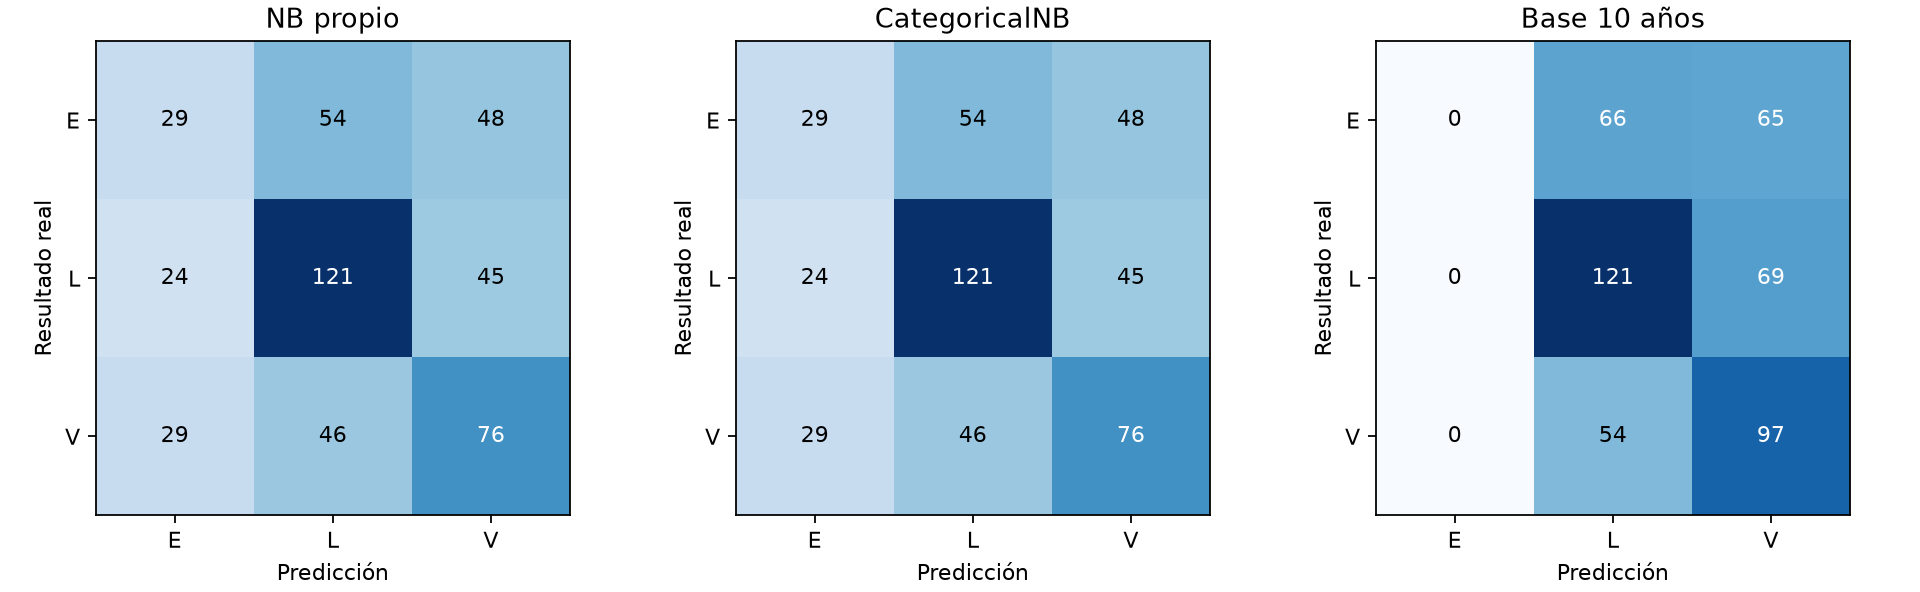

In [9]:
print('Métricas finales:')
display(nb_final['summary'].round(6))
print('Precision, recall, F1 y soporte — E, L, V:')
display(nb_final['class_report'].round(6))
for name, matrix in nb_final['confusion_matrices'].items():
    print(name, '(filas reales; columnas predichas)')
    display(matrix)
from IPython.display import Image
display(Image(filename=str(NB_RESULTS / 'final/confusion_matrices.png')))


### 14.4. Ejemplos concretos y criterio reproducible

Se ordenan las predicciones finales por `date, home, away`, ascendentemente,
y se toma el primer partido de cada par `(winner, pred_nb_propio)` en orden
E/L/V. Así se cubren las nueve celdas no vacías de la matriz, incluidos tres
aciertos y seis errores. No se eligen por equipos conocidos, marcador o
confianza. Es una selección ilustrativa por tipo de resultado, no una muestra
representativa de sus frecuencias; favorece fechas tempranas.

Los marcadores se unen desde el ZIP original tras aplicar la misma política
de limpieza, mediante fecha y equipos, con correspondencia uno a uno y
verificación de la clase real. Se usan únicamente para describir los ejemplos.

| Fecha | Local | Visitante | Marcador real (L-V) | Real | NB (ambos) | Base |
|---|---|---|:---:|:---:|:---:|:---:|
| 2024-03-11 | Montevideo Wanderers | Deportivo Maldonado | 0-0 | E | E | L |
| 2024-02-25 | Cerro Largo FC | CA Fenix | 0-0 | E | L | L |
| 2024-02-18 | CA Cerro | Montevideo Wanderers | 1-1 | E | V | V |
| 2024-04-07 | CA Cerro | Rampla Juniors Futbol Club | 3-0 | L | E | L |
| 2024-02-17 | Nacional | River Plate | 2-1 | L | L | L |
| 2024-03-02 | River Plate | Danubio | 1-0 | L | V | L |
| 2024-02-24 | Montevideo Wanderers | Racing Club | 0-1 | V | E | L |
| 2024-02-18 | Deportivo Maldonado | Boston River | 1-2 | V | L | L |
| 2024-02-17 | CA Fenix | Danubio | 1-2 | V | V | V |

Wanderers–Maldonado ilustra un empate recuperado por NB que el baseline pierde.
Cerro–Rampla ilustra el costo opuesto: NB predice empate y el baseline acierta
la victoria local. Cerro Largo–Fenix y Cerro–Wanderers ejemplifican los dos
errores predominantes, E→L y E→V. Estos casos muestran decisiones observadas;
ni el marcador ni estos ejemplos explican por sí solos por qué se produjeron.


In [10]:
# Lectura y unión descriptiva; no se ajusta ni se vuelve a predecir.
nb_predicciones = nb_final['predictions'].copy()
assert len(nb_predicciones) == nb_final['manifest']['split']['test']['rows']
assert nb_predicciones.pred_nb_propio.eq(nb_predicciones.pred_categorical_nb).all()
nb_claves = ['date', 'home', 'away']
nb_marcadores = load_clean_matches(RAW)[nb_claves + ['winner', 'gh', 'ga']].copy()
nb_marcadores['date'] = nb_marcadores.date.dt.strftime('%Y-%m-%d')
nb_casos = nb_predicciones.merge(
    nb_marcadores.rename(columns={'winner': 'winner_original'}),
    on=nb_claves, how='left', validate='one_to_one', indicator=True)
assert nb_casos['_merge'].eq('both').all()
assert nb_casos.winner.eq(nb_casos.winner_original).all()
nb_casos['marcador_real'] = nb_casos.gh.astype(str) + '-' + nb_casos.ga.astype(str)
nb_ejemplos = (
    nb_casos.sort_values(nb_claves, kind='stable')
    .drop_duplicates(['winner', 'pred_nb_propio'], keep='first')
    .sort_values(['winner', 'pred_nb_propio'], kind='stable'))
display(nb_ejemplos[nb_claves + ['marcador_real', 'winner', 'pred_nb_propio',
                                 'pred_categorical_nb', 'pred_baseline_10y']])
print('Criterio: primer partido por fecha/local/visitante de cada par real/predicción.')


Criterio: primer partido por fecha/local/visitante de cada par real/predicción.


,date,home,away,marcador_real,winner,pred_nb_propio,pred_categorical_nb,pred_baseline_10y
29,2024-03-11,Montevideo Wanderers,Deportivo Maldonado,0-0,E,E,E,L
11,2024-02-25,Cerro Largo FC,CA Fenix,0-0,E,L,L,L
3,2024-02-18,CA Cerro,Montevideo Wanderers,1-1,E,V,V,V
52,2024-04-07,CA Cerro,Rampla Juniors Futbol Club,3-0,L,E,E,L
2,2024-02-17,Nacional,River Plate,2-1,L,L,L,L
17,2024-03-02,River Plate,Danubio,1-0,L,V,V,L
9,2024-02-24,Montevideo Wanderers,Racing Club,0-1,V,E,E,L
4,2024-02-18,Deportivo Maldonado,Boston River,1-2,V,L,L,L
0,2024-02-17,CA Fenix,Danubio,1-2,V,V,V,V


### 14.5. Equivalencia de ambos NB y comparación con el baseline

Se comprueban las predicciones una a una, además de las entradas discretas,
cardinalidades, conteos, priors y puntajes. Con K=4 en los diez atributos,
`(n + m/4)/(n_c + m)` coincide con `(n + alpha)/(n_c + 4*alpha)` para
`alpha=m/4=0.025`. Las diferencias de punto flotante se registran sin cambiar
la decisión por argmax ni el orden de desempate E/L/V.

`disagreements.csv` conserva cualquier discrepancia con identidad del partido,
los puntajes de cada modelo y sus márgenes entre las dos clases mejor puntuadas.


In [11]:
nb_equivalence = nb_final['diagnosis']
print('Predicciones diferentes:', nb_equivalence['n_differences'],
      'de', nb_equivalence['n_predictions'])
print(nb_equivalence['explanation'])
print('Máxima diferencia absoluta de puntajes logarítmicos:',
      nb_equivalence['max_abs_joint_log_likelihood_difference'])
if nb_equivalence['n_differences']:
    display(nb_final['disagreements'])
nb_comparacion = nb_final['summary'].set_index('model')[['accuracy', 'macro_f1']]
nb_comparacion['delta_accuracy_baseline'] = nb_comparacion.accuracy - nb_comparacion.loc['Base 10 años', 'accuracy']
nb_comparacion['delta_macro_f1_baseline'] = nb_comparacion.macro_f1 - nb_comparacion.loc['Base 10 años', 'macro_f1']
display(nb_comparacion.round(6))


Predicciones diferentes: 0 de 472
Los conteos, entradas, dominios y priors coinciden; K=4 y alpha=m/4. Ambas fórmulas son equivalentes salvo redondeo de punto flotante.
Máxima diferencia absoluta de puntajes logarítmicos: 5.329070518200751e-15


,accuracy,macro_f1,delta_accuracy_baseline,delta_macro_f1_baseline
model,,,,
NB propio,0.478814,0.445369,0.016949,0.088923
CategoricalNB,0.478814,0.445369,0.016949,0.088923
Base 10 años,0.461864,0.356446,0.000000,0.000000


### 14.6. Análisis cuantitativo y comparación

E significa empate, L victoria local y V victoria visitante. El test contiene
472 partidos admitidos del 17/02/2024 al 30/06/2025 (297 de 2024 y 175 de
2025; este último año está incompleto). Ambos NB coinciden en las 472
predicciones; por eso el análisis de NB vale para las dos implementaciones.

| Modelo | Aciertos / total | Accuracy | Macro-F1 |
|---|---:|---:|---:|
| NB propio / CategoricalNB | 226/472 | 0.4788 | 0.4454 |
| Baseline de diez años | 218/472 | 0.4619 | 0.3564 |

| Clase | Soporte | Precision NB | Recall NB | F1 NB | Precision base | Recall base | F1 base |
|:---:|---:|---:|---:|---:|---:|---:|---:|
| E | 131 | 0.3537 | 0.2214 | 0.2723 | 0.0000 | 0.0000 | 0.0000 |
| L | 190 | 0.5475 | 0.6368 | 0.5888 | 0.5021 | 0.6368 | 0.5615 |
| V | 151 | 0.4497 | 0.5033 | 0.4750 | 0.4199 | 0.6424 | 0.5079 |

L tiene las mejores precision, recall y F1; V queda en segundo lugar y E
en último. NB predice 82 empates (17.37% del test), aunque hay 131 reales
(27.75%): acierta 29, omite 102 y genera 53 falsos empates. El baseline
no predice E; su precision indefinida para E se informa como cero
(`zero_division=0`). Macro-F1 da igual peso a las tres clases.

Matrices de confusión: filas reales y columnas predichas, en orden E/L/V.

| Real | NB: E | NB: L | NB: V | Base: E | Base: L | Base: V |
|:---:|---:|---:|---:|---:|---:|
| E | 29 | 54 | 48 | 0 | 66 | 65 |
| L | 24 | 121 | 45 | 0 | 121 | 69 |
| V | 29 | 46 | 76 | 0 | 54 | 97 |

De los 246 errores NB, predominan los empates clasificados como victorias:
102 (41.46%), repartidos entre E→L (54, la celda fuera de la diagonal más
frecuente) y E→V (48). Las confusiones L→V (45) y V→L (46) suman 91
(36.99%); las victorias clasificadas como empate suman 53 (21.54%).

NB supera al baseline en 1.69 puntos porcentuales de accuracy y 0.0889 de
macro-F1. Ambos aciertan 153 partidos y ambos fallan 181; NB corrige 73
errores del baseline, pero pierde 65 aciertos de este: saldo +8.
Por clase, NB recupera 29 empates adicionales, conserva 121 aciertos locales
y baja de 97 a 76 aciertos visitantes. El beneficio no es uniforme:
mejoran F1 de E y L, pero empeora F1 de V. Son diferencias descriptivas;
no se evaluó su significación estadística.


In [12]:
# Recalcular métricas desde las predicciones guardadas y contrastar las tablas.
from sklearn.metrics import precision_recall_fscore_support

nb_etiquetas = ['E', 'L', 'V']
for nombre, columna, correcto in [
    ('NB propio', 'pred_nb_propio', 'correct_nb_propio'),
    ('CategoricalNB', 'pred_categorical_nb', 'correct_categorical_nb'),
    ('Base 10 años', 'pred_baseline_10y', 'correct_baseline_10y'),
]:
    real, pred = nb_predicciones.winner, nb_predicciones[columna]
    assert real.eq(pred).eq(nb_predicciones[correcto]).all()
    metricas = [accuracy_score(real, pred),
                f1_score(real, pred, labels=nb_etiquetas, average='macro', zero_division=0)]
    guardadas = nb_final['summary'].set_index('model').loc[nombre, ['accuracy', 'macro_f1']]
    np.testing.assert_allclose(metricas, guardadas.to_numpy(dtype=float))
    np.testing.assert_array_equal(
        confusion_matrix(real, pred, labels=nb_etiquetas),
        nb_final['confusion_matrices'][nombre].loc[nb_etiquetas, nb_etiquetas])
    por_clase = np.column_stack(precision_recall_fscore_support(
        real, pred, labels=nb_etiquetas, zero_division=0))
    tabla = nb_final['class_report'].query('model == @nombre').set_index('class')
    np.testing.assert_allclose(
        por_clase, tabla.loc[nb_etiquetas, ['precision', 'recall', 'f1', 'support']])

print('Comparación pareada (filas: acierto NB, columnas: acierto baseline):')
display(pd.crosstab(nb_predicciones.correct_nb_propio, nb_predicciones.correct_baseline_10y))
nb_errores = (nb_predicciones.loc[~nb_predicciones.correct_nb_propio]
              .groupby(['winner', 'pred_nb_propio']).size().rename('casos').reset_index())
nb_errores['porcentaje_de_errores'] = 100 * nb_errores.casos / nb_errores.casos.sum()
display(nb_errores.sort_values('casos', ascending=False))

# Un solo diagnóstico: signo de la diferencia de puntos recientes, sin umbral ajustado.
nb_atributos = pd.read_csv(NB_RESULTS / 'final/test_features.csv', float_precision='round_trip')
nb_escenarios = nb_predicciones.merge(
    nb_atributos, on=nb_claves + ['winner'], how='left', validate='one_to_one', indicator=True)
assert nb_escenarios['_merge'].eq('both').all()
nb_diferencia = nb_escenarios.home_points_per_match_5 - nb_escenarios.away_points_per_match_5
assert np.isfinite(nb_diferencia).all()
nb_escenarios['escenario'] = np.select(
    [nb_diferencia.gt(0), nb_diferencia.lt(0)], ['Local > visitante', 'Local < visitante'],
    default='Local = visitante')
nb_resumen_escenarios = []
for escenario in ['Local > visitante', 'Local = visitante', 'Local < visitante']:
    grupo = nb_escenarios.loc[nb_escenarios.escenario.eq(escenario)]
    nb_resumen_escenarios.append({
        'escenario': escenario, 'casos': len(grupo),
        'reales_E_L_V': '/'.join(str(int(grupo.winner.eq(c).sum())) for c in nb_etiquetas),
        'aciertos_NB': int(grupo.correct_nb_propio.sum()),
        'accuracy_NB': grupo.correct_nb_propio.mean(),
        'macro_f1_NB': f1_score(grupo.winner, grupo.pred_nb_propio,
                                labels=nb_etiquetas, average='macro', zero_division=0),
        'aciertos_base': int(grupo.correct_baseline_10y.sum()),
        'accuracy_base': grupo.correct_baseline_10y.mean(),
    })
nb_resumen_escenarios = pd.DataFrame(nb_resumen_escenarios)
assert nb_resumen_escenarios.casos.sum() == len(nb_predicciones)
assert nb_resumen_escenarios.aciertos_NB.sum() == nb_predicciones.correct_nb_propio.sum()
display(nb_resumen_escenarios.round(4))
print('Diagnóstico descriptivo posterior al test; no modifica la configuración cerrada.')


Comparación pareada (filas: acierto NB, columnas: acierto baseline):
Diagnóstico descriptivo posterior al test; no modifica la configuración cerrada.


correct_baseline_10y,False,True
correct_nb_propio,,
False,181,65
True,73,153


,winner,pred_nb_propio,casos,porcentaje_de_errores
0,E,L,54,21.951220
1,E,V,48,19.512195
5,V,L,46,18.699187
3,L,V,45,18.292683
4,V,E,29,11.788618
2,L,E,24,9.756098


,escenario,casos,reales_E_L_V,aciertos_NB,accuracy_NB,macro_f1_NB,aciertos_base,accuracy_base
0,Local > visitante,216,62/106/48,116,0.5370,0.3788,99,0.4583
1,Local = visitante,39,9/15/15,15,0.3846,0.3737,21,0.5385
2,Local < visitante,217,60/69/88,95,0.4378,0.3741,98,0.4516


### 14.7. Escenario observable antes del partido

Como diagnóstico posterior a la evaluación, se particiona **todo** el test por
el signo de `home_points_per_match_5 - away_points_per_match_5`: mayor,
igual o menor que cero. Son los promedios guardados de hasta cinco partidos
anteriores de cada equipo, no necesariamente cinco partidos consecutivos del
calendario. No se buscan umbrales ni se escoge el mejor entre varios cortes.
La igualdad usa exactamente los valores almacenados, leídos con
`float_precision='round_trip'`. La partición es exhaustiva y disjunta.

| Puntos recientes | Casos | Reales E/L/V | Aciertos NB | Accuracy NB | Aciertos base | Accuracy base |
|---|---:|:---:|---:|---:|---:|---:|
| Local > visitante | 216 | 62/106/48 | 116 | 53.70% | 99 | 45.83% |
| Local = visitante | 39 | 9/15/15 | 15 | 38.46% | 21 | 53.85% |
| Local < visitante | 217 | 60/69/88 | 95 | 43.78% | 98 | 45.16% |

**Hecho observado:** NB tiene mayor accuracy cuando el local presenta mayor
promedio reciente: 116/216, frente a 95/217 con ventaja visitante y 15/39 con
igualdad. Frente al baseline gana 17 aciertos en el primer grupo y pierde 6 y
3 en los restantes. La diferencia entre ventaja local e igualdad es de
15.24 puntos porcentuales, pero el grupo de igualdad tiene solo 39 casos.

**Posible explicación, no comprobada:** la ventaja reciente local podría ser
una señal más útil para estas predicciones. También cambia la composición
de clases: hay 106 victorias locales entre los 216 casos con ventaja local,
frente a 15 entre los 39 con igualdad, y L es la clase mejor reconocida.
No se aisló el efecto de la forma reciente respecto de esa composición ni de
los demás atributos. El mayor accuracy no implica una mejora uniforme:
el macro-F1 NB de estos grupos es 0.3788, 0.3737 y 0.3741, respectivamente.
Estas observaciones no constituyen una regla nueva de predicción, ni se usaron
para seleccionar modelos, atributos, cortes o hiperparámetros.


### 14.8. Limitaciones y alcance de las explicaciones

- **Discretización:** los dos cortes fijos 0.3/0.6 de las tasas recientes y
  los terciles aprendidos en train para los otros ocho atributos reducen
  números a tres bines (más el código cero reservado). Valores distintos
  dentro de un bin resultan indistinguibles y valores próximos a un corte
  pueden separarse. Por ejemplo, tasas recientes 0.0 y 0.2 comparten bin.
  Esto describe pérdida de resolución; no demuestra que produzca los
  errores listados. No se compararon nuevos cortes con test.
- **Atributos históricos:** los promedios resumen ventanas de diferente
  extensión y omiten parte del contexto del partido. Cinco antecedentes
  pueden cubrir lapsos distintos; el historial completo puede mezclar
  épocas y el de enfrentamientos puede tener soportes distintos. Las diez
  entradas no incluyen sus denominadores, por lo que tasas iguales no
  distinguen la cantidad de evidencia que las respalda. La tasa neutra 0.5
  también puede ser una proporción observada (por ejemplo, una victoria en
  dos partidos): **0.5 no demuestra falta de historial**. Para atribuir un
  caso a esa ausencia harían falta los conteos previos de la ventana y
  equipo correspondientes; aquí no se infiere esa condición.
- **Independencia condicional:** NB multiplica las probabilidades de los
  atributos dada E, L o V. Tasas de victorias, puntos y diferencia de gol
  resumen partidos que se superponen; esto hace plausible que compartan
  información y que tratarla como independiente distorsione los puntajes.
  La superposición por sí sola no prueba dependencia condicionada a la
  clase. No se midió esa dependencia ni se hizo una comparación que aísle
  su efecto; no se atribuye ningún error concreto a esta hipótesis.
- **Generalización:** los resultados describen estos 472 registros admitidos,
  con 2025 incompleto. Los historiales incluyen resultados de fechas
  estrictamente anteriores, incluso del test, y no se actualizan con el
  partido actual ni otros del mismo día. Es evaluación secuencial; no una
  predicción simultánea de todo 2024–2025 desde 2023. Los modelos y
  discretizadores permanecen fijos. Las diferencias de grupos y modelos
  no prueban causalidad ni garantizan desempeño futuro.

El análisis responde al apartado 3 de `Tarea_1.pdf` en el alcance solicitado:
NB propio, NB de scikit-learn y baseline. La evaluación pendiente de árboles
y Random Forest no se completa con estos resultados.


## Estado de la evaluación

La evaluación final y el análisis cuantitativo y cualitativo de ambos NB y del
baseline causal están completos. Los artefactos originales permanecen en
`results/naive_bayes/final/`. La documentación técnica está en
`docs/nb_final_evaluation.md` y el texto conciso para el informe en
`docs/nb_analisis_informe.md`. ID3 y Random Forest quedan fuera de esta ejecución.
